# Genre Investment Analysis for Record Labels
## A Data-Driven Approach to Music Genre Portfolio Strategy

**Course:** ACC102 Mini Assignment-Track4(interative tool)

**Dataset:** Spotify Global Streaming Data 2024  

**Target User:** A&R (Artist & Repertoire) decision-makers at a record label  

---

### Core Business Question

> Among all music genres on Spotify's global platform, which genres offer the best 
> commercial return for a record label's next investment cycle — and should the label 
> prioritize streaming volume, listener engagement, or paid subscription revenue?

### Approach

1. **Full-landscape scan**: Analyse all 10 genres to identify overall patterns  
2. **Deep-dive**: Focus on selected genres of strategic interest  
3. **Regional analysis**: Map genre preferences across 20 countries  
4. **Investment recommendation**: Data-backed portfolio strategy

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# 0. SETUP & CONFIGURATION
# All key parameters are defined here as variables.
# To adapt this analysis for different genres, simply modify FOCUS_GENRES below.
# ══════════════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings('ignore')

# ── CONFIGURATION VARIABLES ──────────────────────────────────────────────────
# ★ Change these to customise the analysis for different genres / files ★
DATA_FILE = 'Cleaned_Spotify_2024_Global_Streaming_Data.csv'
FOCUS_GENRES = ['Pop', 'R&B', 'Rock', 'Jazz']

# Color scheme — one color per genre for consistency across all charts
GENRE_COLORS = {
    'Pop': '#E74C3C', 'R&B': '#9B59B6', 'Rock': '#3498DB', 'Jazz': '#F39C12',
    'Hip Hop': '#2ECC71', 'K-pop': '#E91E63', 'EDM': '#00BCD4',
    'Reggaeton': '#FF9800', 'Indie': '#8BC34A', 'Classical': '#795548'
}

# Column name aliases (change if your CSV uses different column headers)
STREAM_COL       = 'Total Streams (Millions)'
LISTENER_COL     = 'Monthly Listeners (Millions)'
DURATION_COL     = 'Avg Stream Duration (Min)'
SKIP_COL         = 'Skip Rate (%)'
HOURS_COL        = 'Total Hours Streamed (Millions)'
PLATFORM_COL     = 'Platform Type'
GENRE_COL        = 'Genre'
COUNTRY_COL      = 'Country'
RECENT_STREAM_COL = 'Streams Last 30 Days (Millions)'
RELEASE_COL      = 'Release Year'

# Chart styling
plt.rcParams.update({
    'figure.dpi': 120, 'savefig.dpi': 150, 'font.size': 11,
    'axes.titlesize': 13, 'axes.labelsize': 11, 'figure.facecolor': 'white'
})
sns.set_style("whitegrid")

print("✓ Setup complete.")
print(f"  Focus genres: {FOCUS_GENRES}")

## 1. Data Loading & Exploration

**Source:** [Kaggle — Spotify Global Streaming Data 2024](https://www.kaggle.com/datasets/atharvasoundankar/spotify-global-streaming-data-2024)  
**Access Date:** April 2026

In [2]:
# ── 1. Data Loading ───────────────────────────────────────────────────────────
df = pd.read_csv(DATA_FILE)

print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nColumn names: {list(df.columns)}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nGenres ({df[GENRE_COL].nunique()}): {sorted(df[GENRE_COL].unique())}")
print(f"Countries ({df[COUNTRY_COL].nunique()}): {sorted(df[COUNTRY_COL].unique())}")
print(f"Platform types: {list(df[PLATFORM_COL].unique())}")
print(f"Release year range: {df[RELEASE_COL].min()} – {df[RELEASE_COL].max()}")

df.head()

Dataset shape: 500 rows × 12 columns

Column names: ['Country', 'Artist', 'Album', 'Genre', 'Release Year', 'Monthly Listeners (Millions)', 'Total Streams (Millions)', 'Total Hours Streamed (Millions)', 'Avg Stream Duration (Min)', 'Platform Type', 'Streams Last 30 Days (Millions)', 'Skip Rate (%)']

Missing values:
Country                            0
Artist                             0
Album                              0
Genre                              0
Release Year                       0
Monthly Listeners (Millions)       0
Total Streams (Millions)           0
Total Hours Streamed (Millions)    0
Avg Stream Duration (Min)          0
Platform Type                      0
Streams Last 30 Days (Millions)    0
Skip Rate (%)                      0
dtype: int64

Genres (10): ['Classical', 'EDM', 'Hip Hop', 'Indie', 'Jazz', 'K-pop', 'Pop', 'R&B', 'Reggaeton', 'Rock']
Countries (20): ['Argentina', 'Australia', 'Brazil', 'Canada', 'France', 'Germany', 'India', 'Indonesia', 'Italy', 'Ja

,Country,Artist,Album,Genre,Release Year,Monthly Listeners (Millions),Total Streams (Millions),Total Hours Streamed (Millions),Avg Stream Duration (Min),Platform Type,Streams Last 30 Days (Millions),Skip Rate (%)
0,Germany,Taylor Swift,1989 (Taylor's Version),K-pop,2020,23.10,3695.53,14240.35,4.28,Free,118.51,2.24
1,Brazil,The Weeknd,After Hours,R&B,2023,60.60,2828.16,11120.44,3.90,Premium,44.87,23.98
2,United States,Post Malone,Austin,Reggaeton,2019,42.84,1425.46,4177.49,4.03,Free,19.46,4.77
3,Italy,Ed Sheeran,Autumn Variations,K-pop,2019,73.24,2704.33,12024.08,3.26,Premium,166.05,25.12
4,Italy,Ed Sheeran,Autumn Variations,R&B,2019,7.89,3323.25,13446.32,4.47,Free,173.43,15.82


## 2. Full Landscape: All 10 Genres Compared

Before narrowing to our focus genres, we examine **all 10 genres** to understand the overall market. This ensures we don't miss important patterns and provides context for our deep-dive.

In [3]:
# ── 2a. Key Metrics for All Genres ────────────────────────────────────────────
all_metrics = df.groupby(GENRE_COL).agg(
    Avg_Streams       = (STREAM_COL, 'mean'),
    Avg_Listeners     = (LISTENER_COL, 'mean'),
    Avg_Duration      = (DURATION_COL, 'mean'),
    Avg_Skip_Rate     = (SKIP_COL, 'mean'),
    Avg_Hours         = (HOURS_COL, 'mean'),
    Avg_Recent_Streams= (RECENT_STREAM_COL, 'mean'),
    Song_Count        = (STREAM_COL, 'count')
).round(2).sort_values('Avg_Streams', ascending=False)

# Add estimated revenue per song (industry avg ~$0.004/stream)
PER_STREAM_RATE = 0.004
all_metrics['Est_Revenue_Per_Song ($M)'] = (all_metrics['Avg_Streams'] * PER_STREAM_RATE).round(2)

all_metrics

,Avg_Streams,Avg_Listeners,Avg_Duration,Avg_Skip_Rate,Avg_Hours,Avg_Recent_Streams,Song_Count,Est_Revenue_Per_Song ($M)
Genre,,,,,,,,
R&B,2779.31,50.12,3.62,19.89,9751.40,94.30,41,11.12
K-pop,2760.69,51.11,3.51,19.11,9663.07,102.68,48,11.04
Classical,2739.96,55.13,3.54,19.80,9377.06,99.40,72,10.96
Pop,2686.80,50.55,3.44,23.13,9617.50,95.09,44,10.75
Indie,2661.67,51.24,3.50,18.29,9084.21,111.50,50,10.65
Rock,2558.95,54.65,3.53,21.14,8876.97,101.81,58,10.24
EDM,2466.70,50.84,3.52,20.79,8885.97,78.49,51,9.87
Jazz,2408.46,52.79,3.43,20.00,7973.73,86.97,43,9.63
Reggaeton,2404.31,46.20,3.56,20.10,8348.08,114.04,44,9.62


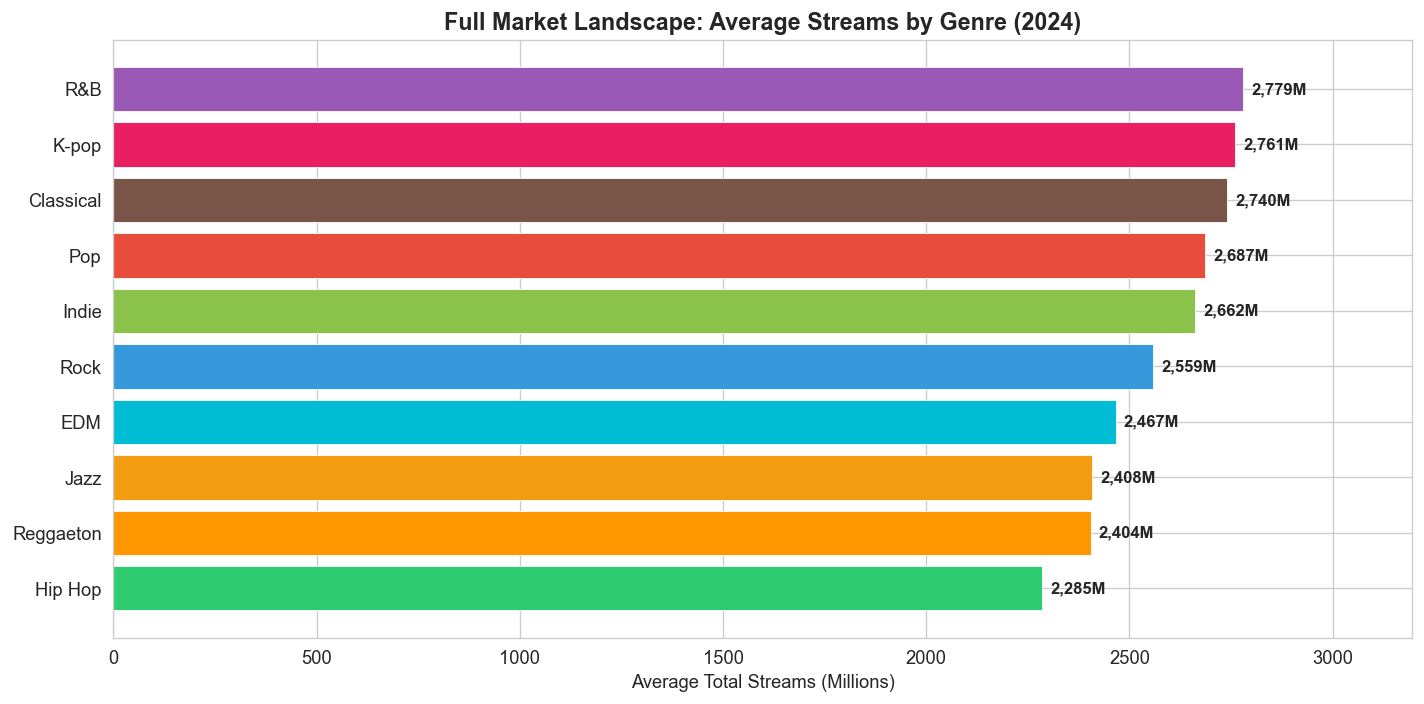

In [4]:
# ── Figure 1: All Genres — Average Total Streams ─────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))
sorted_genres = all_metrics.index.tolist()
colors_list = [GENRE_COLORS.get(g, '#888') for g in sorted_genres]

bars = ax.barh(sorted_genres[::-1], all_metrics['Avg_Streams'].values[::-1],
               color=colors_list[::-1], edgecolor='white', linewidth=0.5)

for bar in bars:
    w = bar.get_width()
    ax.text(w + 20, bar.get_y() + bar.get_height()/2,
            f'{w:,.0f}M', va='center', fontweight='bold', fontsize=10)

ax.set_xlabel('Average Total Streams (Millions)')
ax.set_title('Full Market Landscape: Average Streams by Genre (2024)',
             fontweight='bold', fontsize=14)
ax.set_xlim(0, max(all_metrics['Avg_Streams']) * 1.15)
plt.tight_layout()
plt.savefig('figure_1_all_genres_streams.png', bbox_inches='tight')
plt.show()

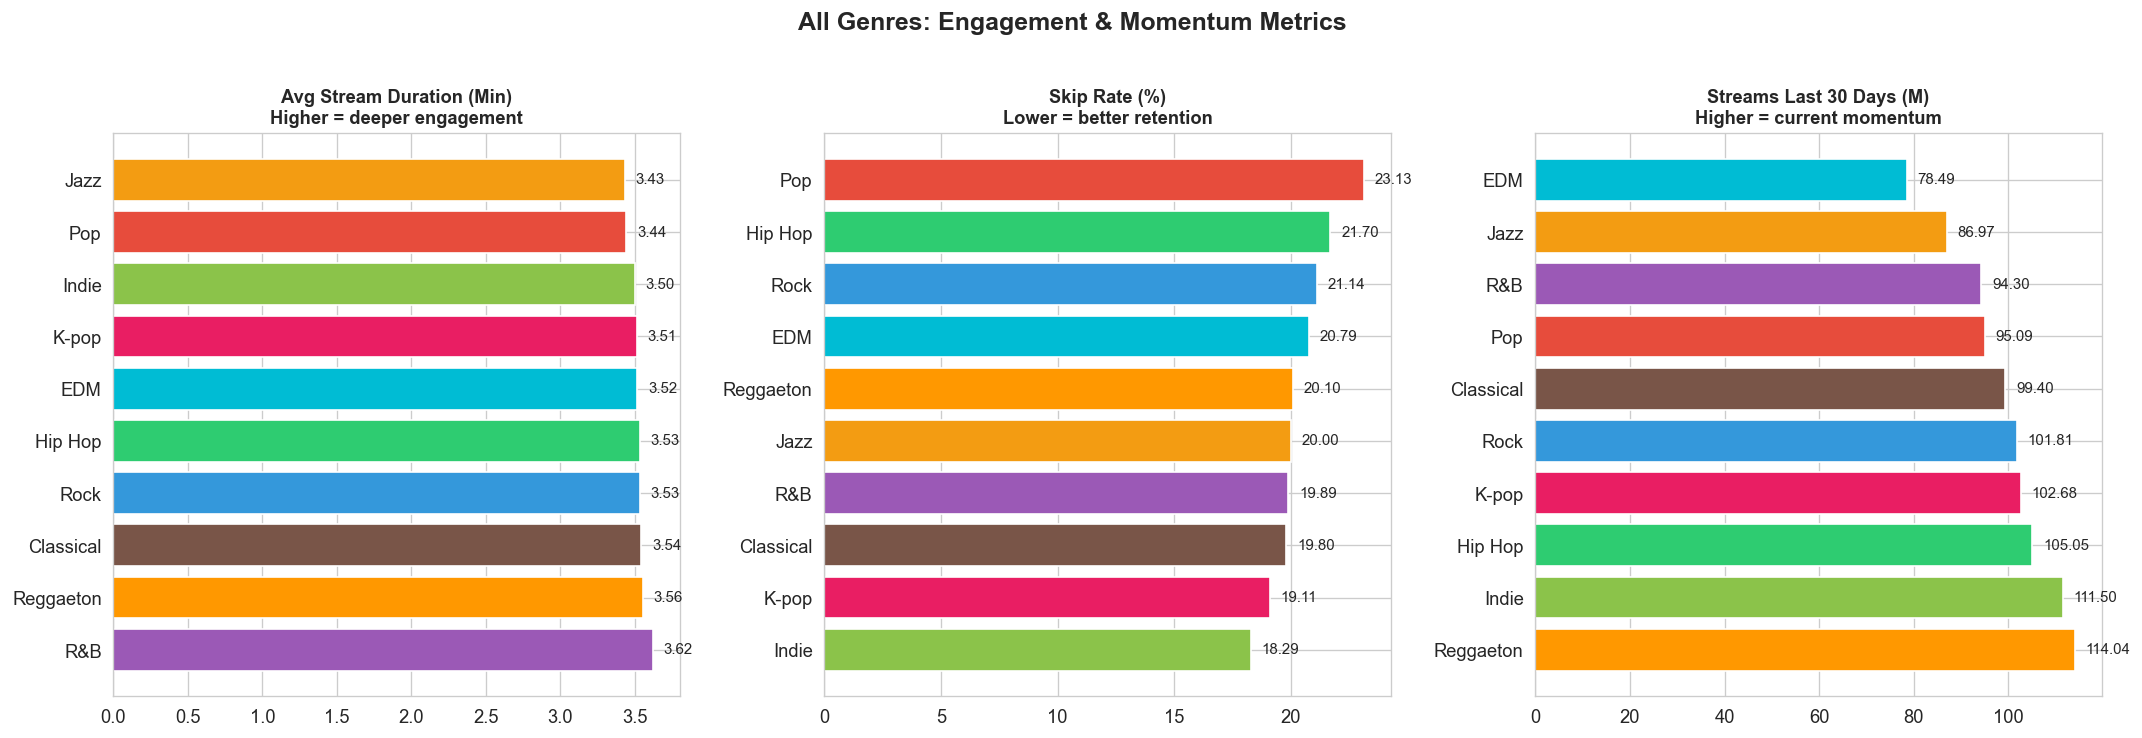

In [5]:
# ── Figure 2: All Genres — Engagement Metrics Side by Side ────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('All Genres: Engagement & Momentum Metrics', fontsize=15, fontweight='bold', y=1.02)

panels = [
    (DURATION_COL, 'Avg Stream Duration (Min)\nHigher = deeper engagement'),
    (SKIP_COL, 'Skip Rate (%)\nLower = better retention'),
    (RECENT_STREAM_COL, 'Streams Last 30 Days (M)\nHigher = current momentum')
]

for idx, (col, title) in enumerate(panels):
    data = df.groupby(GENRE_COL)[col].mean().sort_values(ascending=(idx == 1))
    c = [GENRE_COLORS.get(g, '#888') for g in data.index]
    axes[idx].barh(data.index, data.values, color=c, edgecolor='white')
    axes[idx].set_title(title, fontweight='bold', fontsize=11)
    for i, v in enumerate(data.values):
        axes[idx].text(v + data.max()*0.02, i, f'{v:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('figure_2_all_genres_engagement.png', bbox_inches='tight')
plt.show()

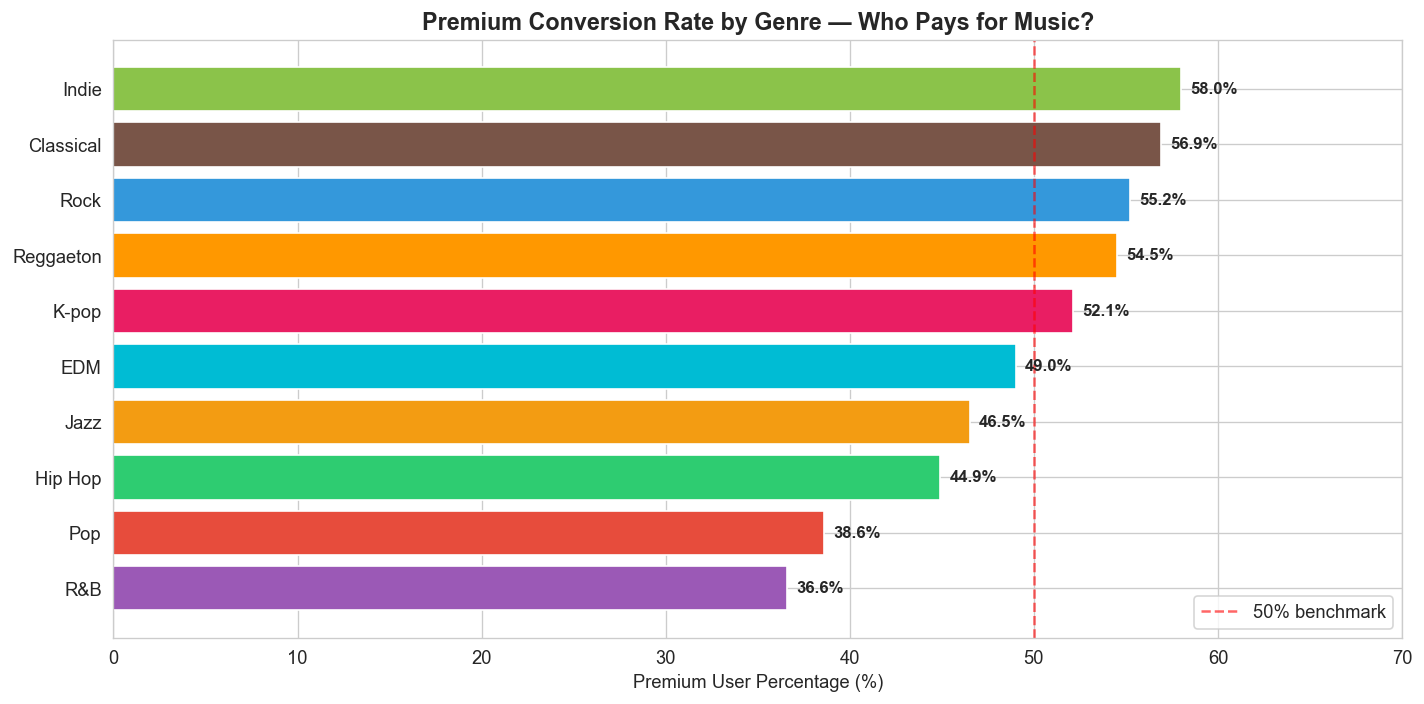

In [6]:
# ── Figure 3: Premium Conversion Rate — All Genres ────────────────────────────
plat = df.groupby([GENRE_COL, PLATFORM_COL]).size().unstack(fill_value=0)
plat['Total'] = plat.sum(axis=1)
plat['Premium_Pct'] = (plat['Premium'] / plat['Total'] * 100).round(1)
plat = plat.sort_values('Premium_Pct', ascending=True)

fig, ax = plt.subplots(figsize=(12, 6))
c = [GENRE_COLORS.get(g, '#888') for g in plat.index]
bars = ax.barh(plat.index, plat['Premium_Pct'], color=c, edgecolor='white')
ax.axvline(x=50, color='red', linestyle='--', alpha=0.6, label='50% benchmark')

for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.5, bar.get_y() + bar.get_height()/2,
            f'{w:.1f}%', va='center', fontweight='bold', fontsize=10)

ax.set_xlabel('Premium User Percentage (%)')
ax.set_title('Premium Conversion Rate by Genre — Who Pays for Music?',
             fontweight='bold', fontsize=14)
ax.legend(loc='lower right')
ax.set_xlim(0, 70)
plt.tight_layout()
plt.savefig('figure_3_all_genres_premium.png', bbox_inches='tight')
plt.show()

## 3. Deep Dive: Focus Genres

Based on the full landscape scan, we now zoom into our four focus genres: **Pop, R&B, Rock, and Jazz**.

> **Reusability:** To analyse different genres, simply change the `FOCUS_GENRES` variable in Cell 2 and re-run all cells.

In [7]:
# ── 3. Filter to Focus Genres ─────────────────────────────────────────────────
df_focus = df[df[GENRE_COL].isin(FOCUS_GENRES)].copy()
print(f"Filtered to {len(FOCUS_GENRES)} genres: {FOCUS_GENRES}")
print(f"Observations: {len(df_focus)} ({len(df_focus)/len(df)*100:.1f}% of total)")
print(f"\nBreakdown:\n{df_focus[GENRE_COL].value_counts()}")

Filtered to 4 genres: ['Pop', 'R&B', 'Rock', 'Jazz']
Observations: 186 (37.2% of total)

Breakdown:
Genre
Rock    58
Pop     44
Jazz    43
R&B     41
Name: count, dtype: int64


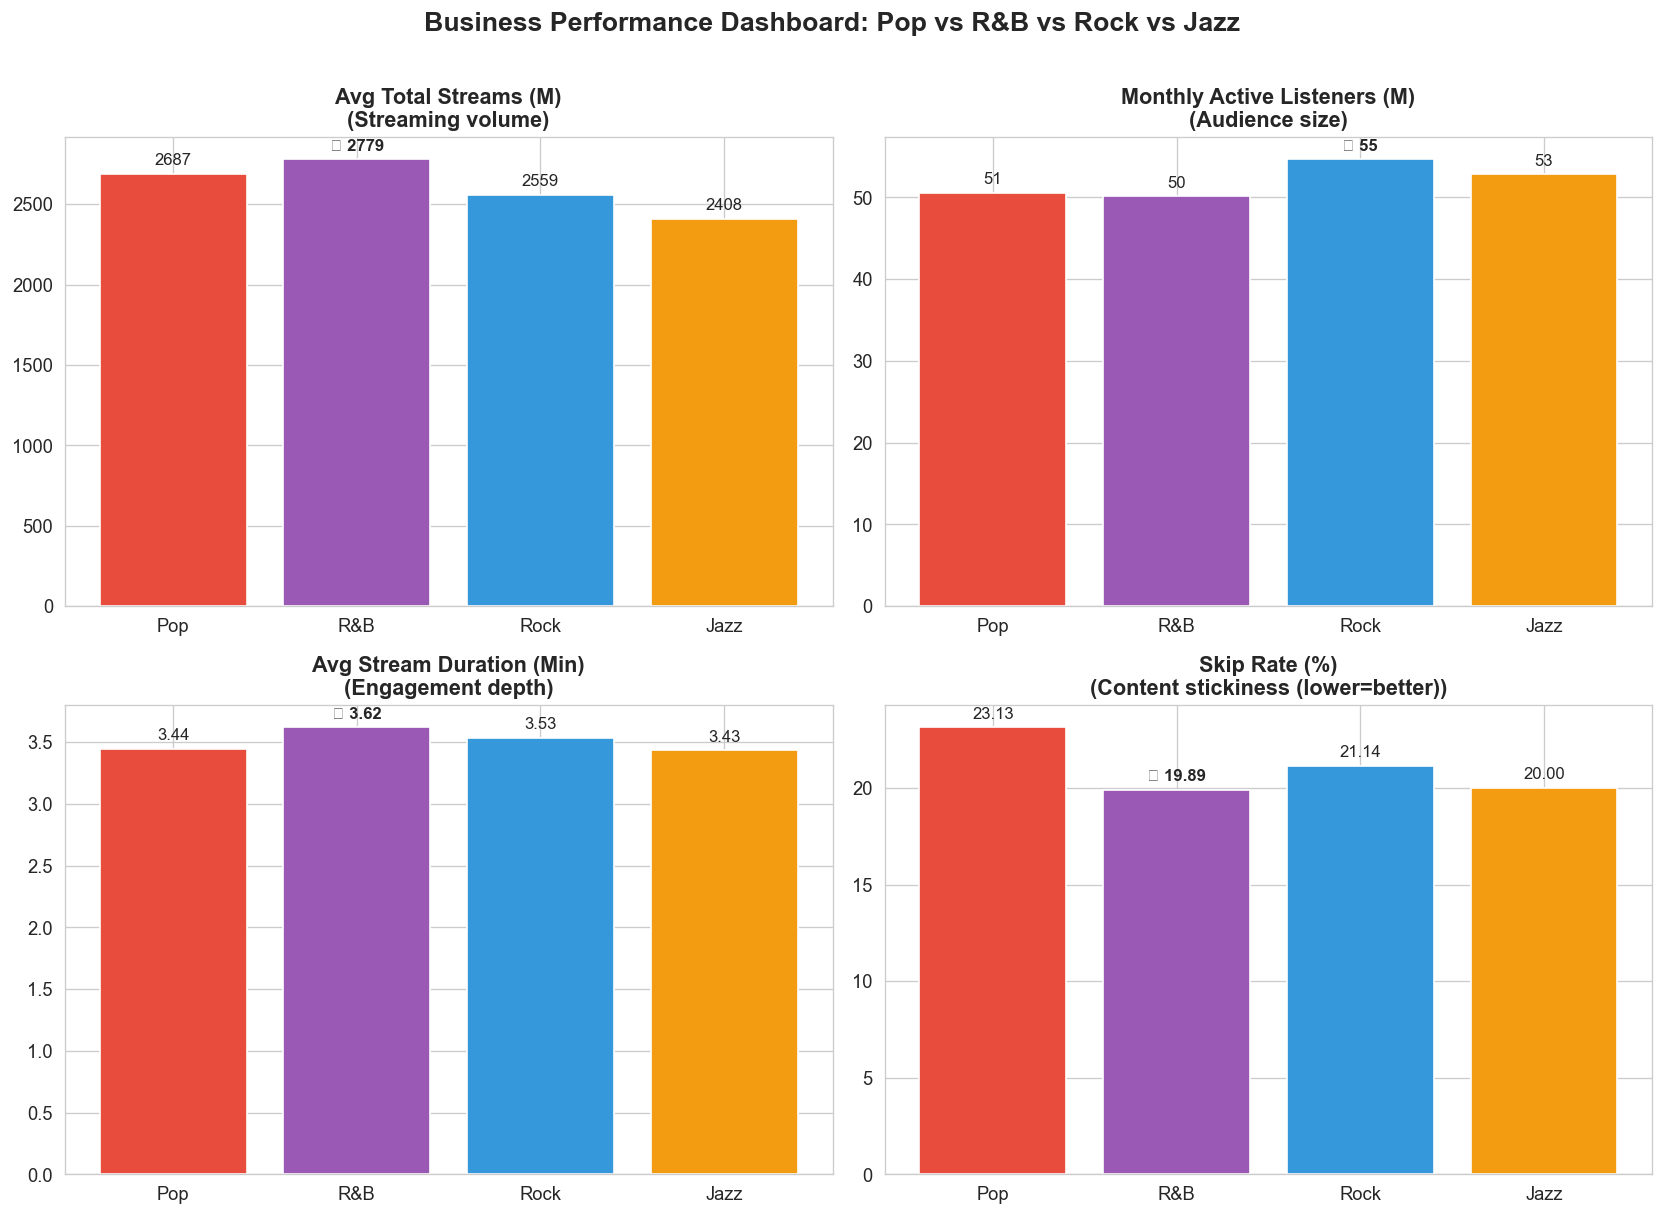

In [8]:
# ── Figure 4: Focus Genres — Business Performance Dashboard ──────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'Business Performance Dashboard: {" vs ".join(FOCUS_GENRES)}',
             fontsize=16, fontweight='bold', y=1.01)

panels = [
    (STREAM_COL, 'Avg Total Streams (M)', 'Streaming volume'),
    (LISTENER_COL, 'Monthly Active Listeners (M)', 'Audience size'),
    (DURATION_COL, 'Avg Stream Duration (Min)', 'Engagement depth'),
    (SKIP_COL, 'Skip Rate (%)', 'Content stickiness (lower=better)')
]

for idx, (col, title, sub) in enumerate(panels):
    ax = axes[idx//2][idx%2]
    data = df_focus.groupby(GENRE_COL)[col].mean().reindex(FOCUS_GENRES)
    bc = [GENRE_COLORS[g] for g in FOCUS_GENRES]
    bars = ax.bar(FOCUS_GENRES, data.values, color=bc, edgecolor='white')
    ax.set_title(f'{title}\n({sub})', fontweight='bold')
    
    best = data.values.argmax() if idx != 3 else data.values.argmin()
    for i, (bar, val) in enumerate(zip(bars, data.values)):
        fmt = f'{val:.2f}' if idx >= 2 else f'{val:.0f}'
        label = f'★ {fmt}' if i == best else fmt
        ax.text(bar.get_x()+bar.get_width()/2, val+data.max()*0.02,
                label, ha='center', fontweight='bold' if i==best else 'normal', fontsize=10)

plt.tight_layout()
plt.savefig('figure_4_focus_dashboard.png', bbox_inches='tight')
plt.show()

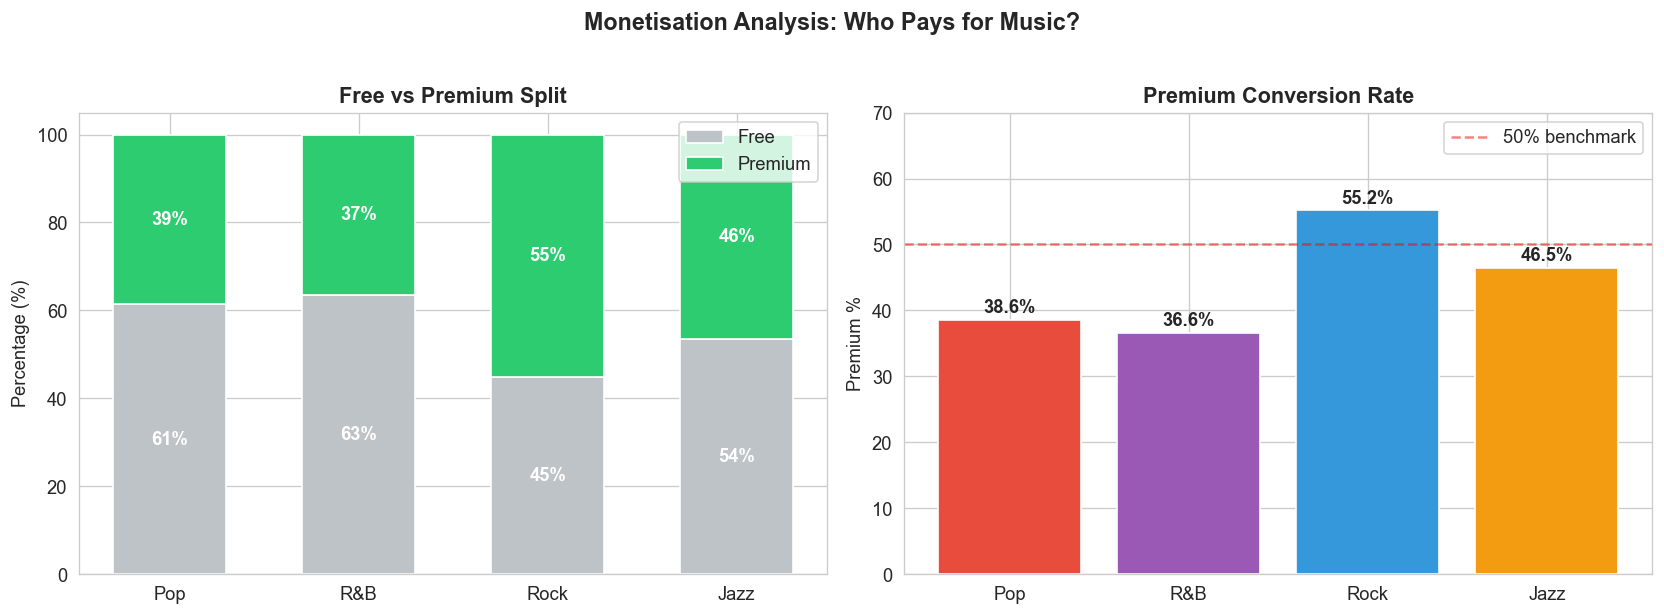

In [9]:
# ── Figure 5: Free vs Premium — Focus Genres ─────────────────────────────────
pf = df_focus.groupby([GENRE_COL, PLATFORM_COL]).size().unstack(fill_value=0).reindex(FOCUS_GENRES)
pf['Total'] = pf.sum(axis=1)
pf['Premium_Pct'] = (pf['Premium'] / pf['Total'] * 100).round(1)
pf['Free_Pct'] = (pf['Free'] / pf['Total'] * 100).round(1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Monetisation Analysis: Who Pays for Music?', fontsize=14, fontweight='bold', y=1.02)

x = np.arange(len(FOCUS_GENRES))
ax1.bar(x, pf['Free_Pct'], 0.6, label='Free', color='#BDC3C7', edgecolor='white')
ax1.bar(x, pf['Premium_Pct'], 0.6, bottom=pf['Free_Pct'], label='Premium', color='#2ECC71', edgecolor='white')
for i, (fp, pp) in enumerate(zip(pf['Free_Pct'], pf['Premium_Pct'])):
    ax1.text(i, fp/2, f'{fp:.0f}%', ha='center', va='center', fontweight='bold', color='white')
    ax1.text(i, fp+pp/2, f'{pp:.0f}%', ha='center', va='center', fontweight='bold', color='white')
ax1.set_xticks(x); ax1.set_xticklabels(FOCUS_GENRES)
ax1.set_ylabel('Percentage (%)'); ax1.set_title('Free vs Premium Split', fontweight='bold'); ax1.legend()

bars = ax2.bar(FOCUS_GENRES, pf['Premium_Pct'], color=[GENRE_COLORS[g] for g in FOCUS_GENRES], edgecolor='white')
ax2.axhline(y=50, color='red', linestyle='--', alpha=0.5, label='50% benchmark')
for bar, val in zip(bars, pf['Premium_Pct']):
    ax2.text(bar.get_x()+bar.get_width()/2, val+1, f'{val:.1f}%', ha='center', fontweight='bold', fontsize=11)
ax2.set_title('Premium Conversion Rate', fontweight='bold')
ax2.set_ylabel('Premium %'); ax2.set_ylim(0, 70); ax2.legend()

plt.tight_layout()
plt.savefig('figure_5_premium_analysis.png', bbox_inches='tight')
plt.show()

## 4. Regional Analysis: Genre Preferences Across 20 Countries

Understanding geographic variation is critical for a label's go-to-market strategy. Different regions have different genre affinities — this affects marketing spend and artist signing priorities.

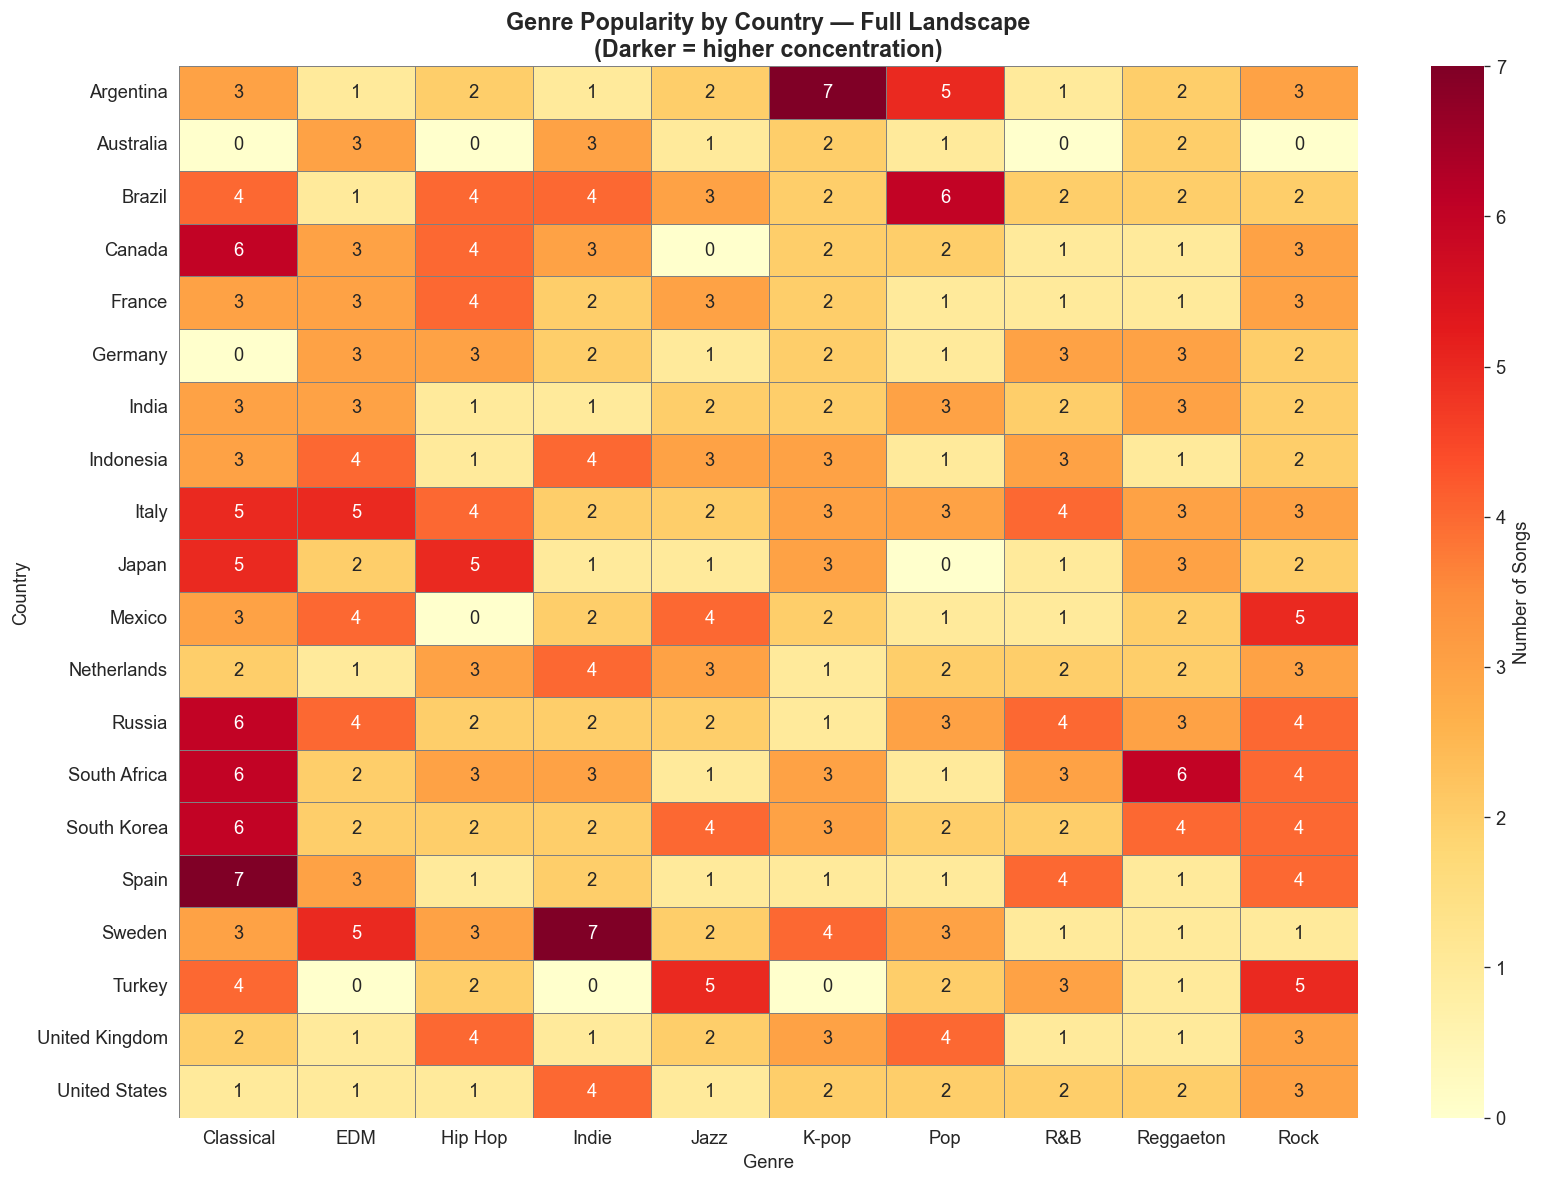

In [10]:
# ── Figure 6: Country × Genre Heatmap (All Genres) ───────────────────────────
genre_country = df.groupby([COUNTRY_COL, GENRE_COL]).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(genre_country, annot=True, fmt='d', cmap='YlOrRd',
            cbar_kws={'label': 'Number of Songs'}, linewidths=0.5, linecolor='gray', ax=ax)
ax.set_title('Genre Popularity by Country — Full Landscape\n(Darker = higher concentration)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figure_6_country_heatmap.png', bbox_inches='tight')
plt.show()

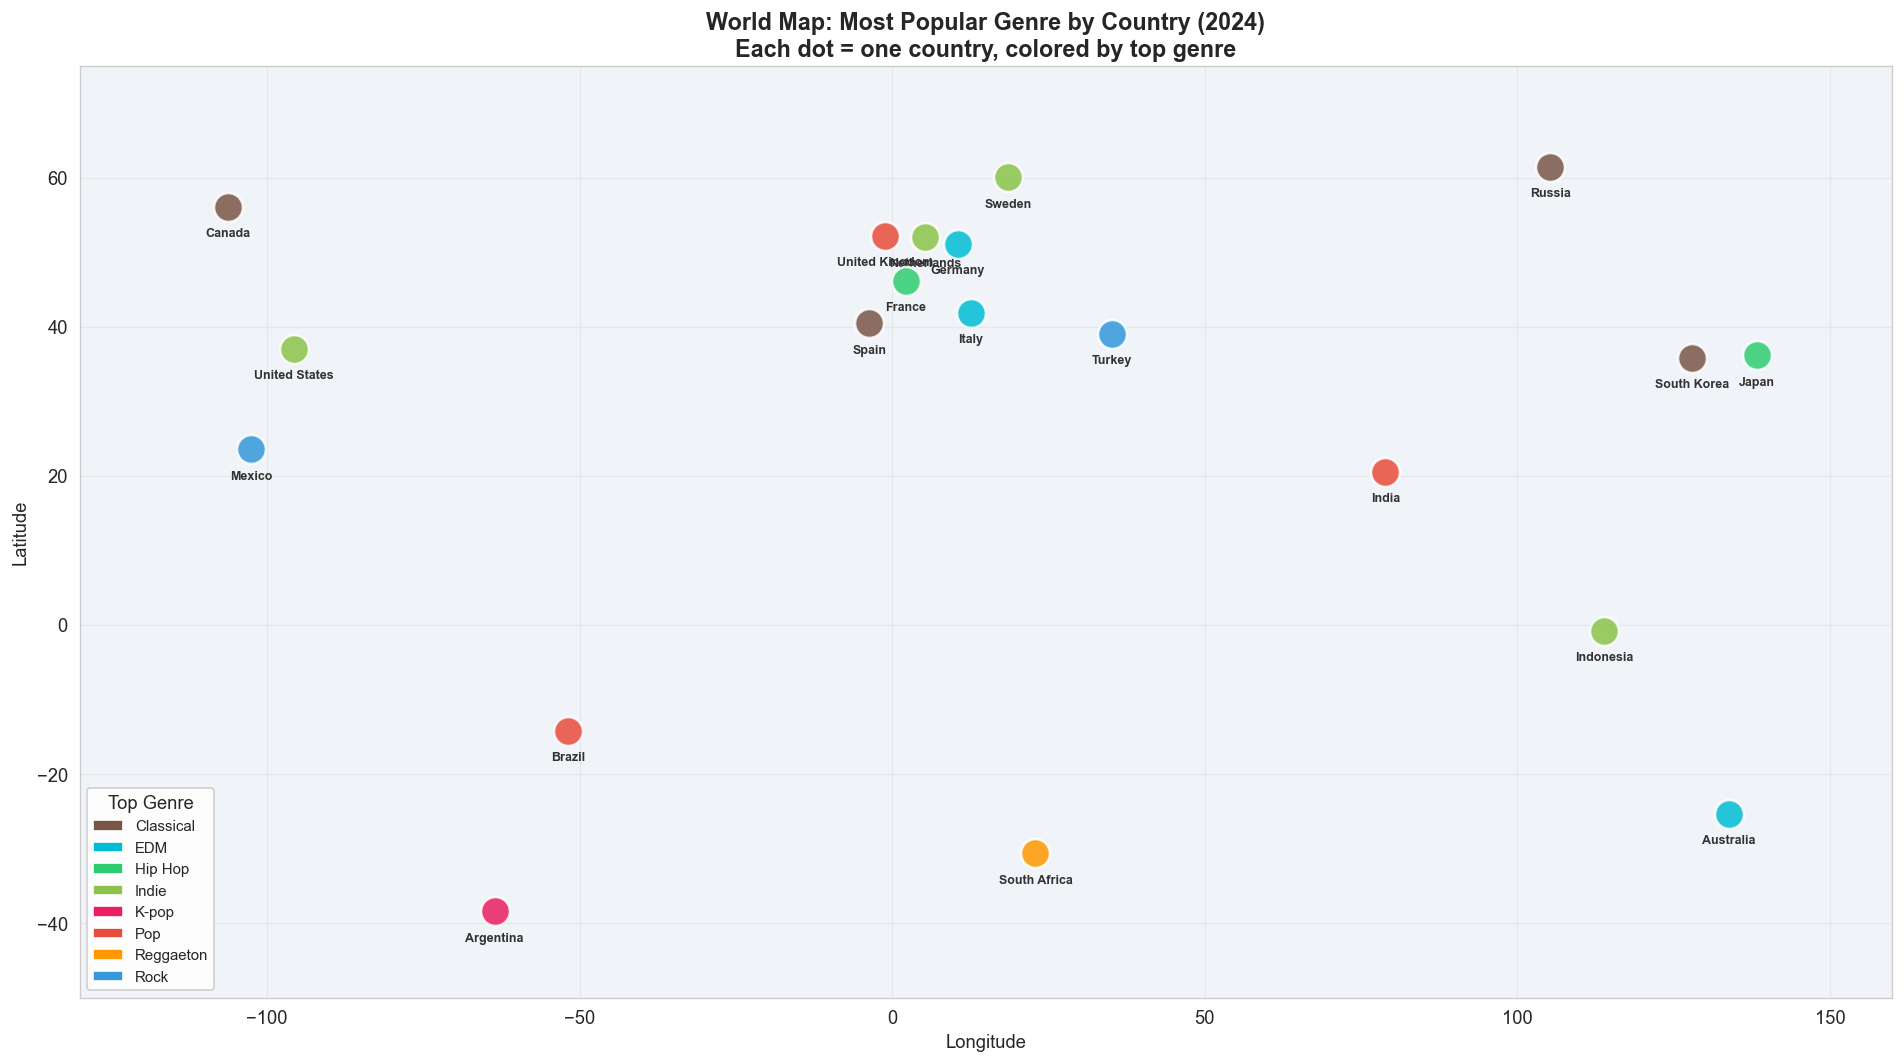

In [11]:
# ── Figure 7: World Map — Top Genre by Country ───────────────────────────────
country_coords = {
    'United States': (-95.7, 37.1), 'United Kingdom': (-1.2, 52.2),
    'Canada': (-106.3, 56.1), 'Brazil': (-51.9, -14.2),
    'Argentina': (-63.6, -38.4), 'Mexico': (-102.6, 23.6),
    'Germany': (10.5, 51.2), 'France': (2.2, 46.2),
    'Spain': (-3.7, 40.5), 'Italy': (12.6, 41.9),
    'Netherlands': (5.3, 52.1), 'Sweden': (18.6, 60.1),
    'Russia': (105.3, 61.5), 'Turkey': (35.2, 39.1),
    'India': (78.9, 20.6), 'Japan': (138.3, 36.2),
    'South Korea': (128.0, 35.9), 'Indonesia': (113.9, -0.8),
    'Australia': (133.8, -25.3), 'South Africa': (22.9, -30.6)
}

top_genre = df.groupby(COUNTRY_COL)[GENRE_COL].agg(lambda x: x.value_counts().index[0])

fig, ax = plt.subplots(figsize=(16, 9))
ax.set_xlim(-130, 160); ax.set_ylim(-50, 75)
ax.set_facecolor('#F0F4F8')

for country, genre in top_genre.items():
    if country in country_coords:
        lon, lat = country_coords[country]
        color = GENRE_COLORS.get(genre, '#888')
        ax.scatter(lon, lat, c=color, s=300, edgecolors='white', linewidth=1.5, zorder=5, alpha=0.85)
        ax.annotate(country, (lon, lat), textcoords="offset points",
                    xytext=(0, -18), ha='center', fontsize=7.5, fontweight='bold', color='#333')

legend_elems = [Patch(facecolor=GENRE_COLORS[g], edgecolor='white', label=g)
                for g in sorted(top_genre.unique())]
ax.legend(handles=legend_elems, loc='lower left', fontsize=9, title='Top Genre', framealpha=0.9)
ax.set_title('World Map: Most Popular Genre by Country (2024)\nEach dot = one country, colored by top genre',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude'); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figure_7_world_map.png', bbox_inches='tight')
plt.show()

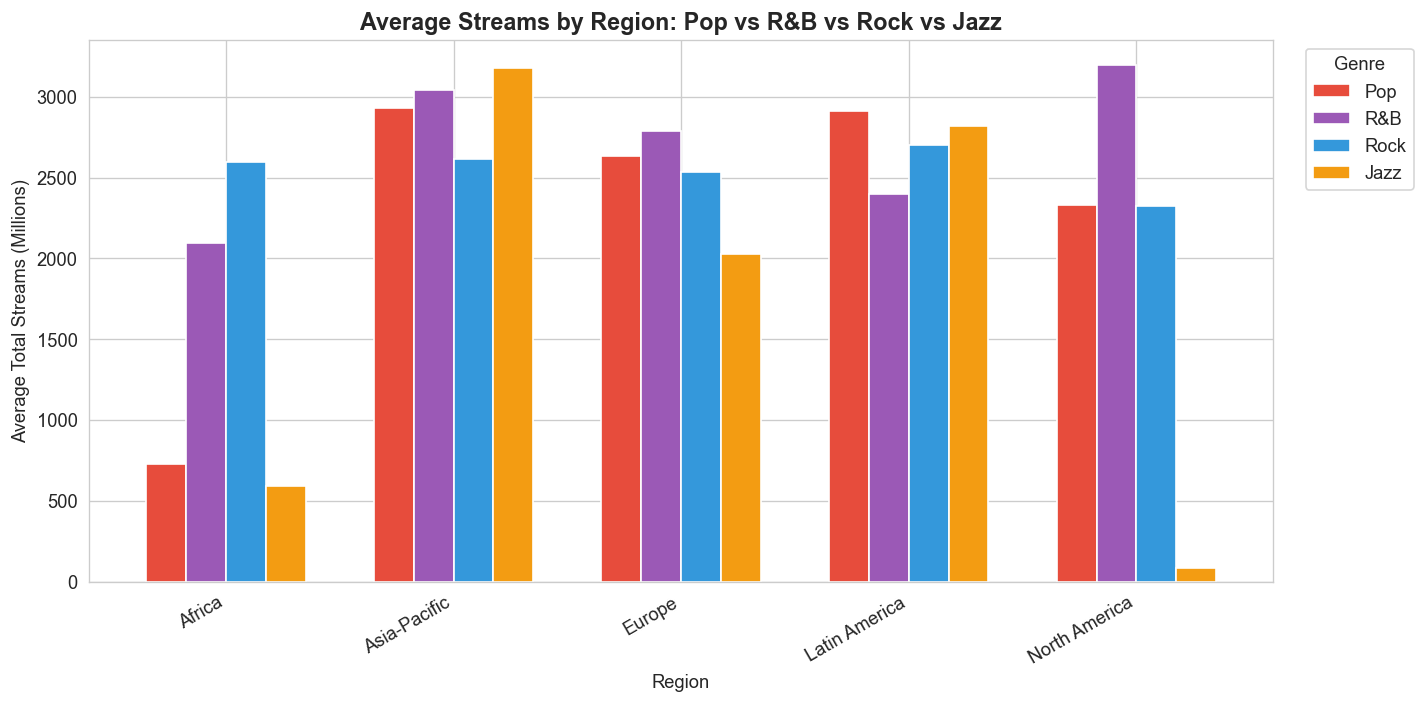

In [12]:
# ── Figure 8: Regional Analysis — Focus Genres by World Region ────────────────
REGION_MAP = {
    'United States': 'North America', 'Canada': 'North America',
    'Mexico': 'Latin America', 'Brazil': 'Latin America', 'Argentina': 'Latin America',
    'United Kingdom': 'Europe', 'Germany': 'Europe', 'France': 'Europe',
    'Spain': 'Europe', 'Italy': 'Europe', 'Netherlands': 'Europe', 'Sweden': 'Europe',
    'Russia': 'Europe', 'Turkey': 'Europe',
    'India': 'Asia-Pacific', 'Japan': 'Asia-Pacific',
    'South Korea': 'Asia-Pacific', 'Indonesia': 'Asia-Pacific', 'Australia': 'Asia-Pacific',
    'South Africa': 'Africa'
}
df['Region'] = df[COUNTRY_COL].map(REGION_MAP)

region_genre = df[df[GENRE_COL].isin(FOCUS_GENRES)].groupby(['Region', GENRE_COL])[STREAM_COL].mean().unstack(fill_value=0)
region_genre = region_genre.reindex(columns=FOCUS_GENRES)

fig, ax = plt.subplots(figsize=(12, 6))
region_genre.plot(kind='bar', ax=ax, color=[GENRE_COLORS[g] for g in FOCUS_GENRES],
                  edgecolor='white', width=0.7)
ax.set_title(f'Average Streams by Region: {" vs ".join(FOCUS_GENRES)}', fontweight='bold', fontsize=14)
ax.set_ylabel('Average Total Streams (Millions)'); ax.set_xlabel('Region')
ax.legend(title='Genre', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('figure_8_regional_analysis.png', bbox_inches='tight')
plt.show()

## 5. Advanced Analysis: Correlation & Revenue Estimation

To give A&R teams a more actionable view, we examine correlations between metrics and estimate revenue potential per genre.

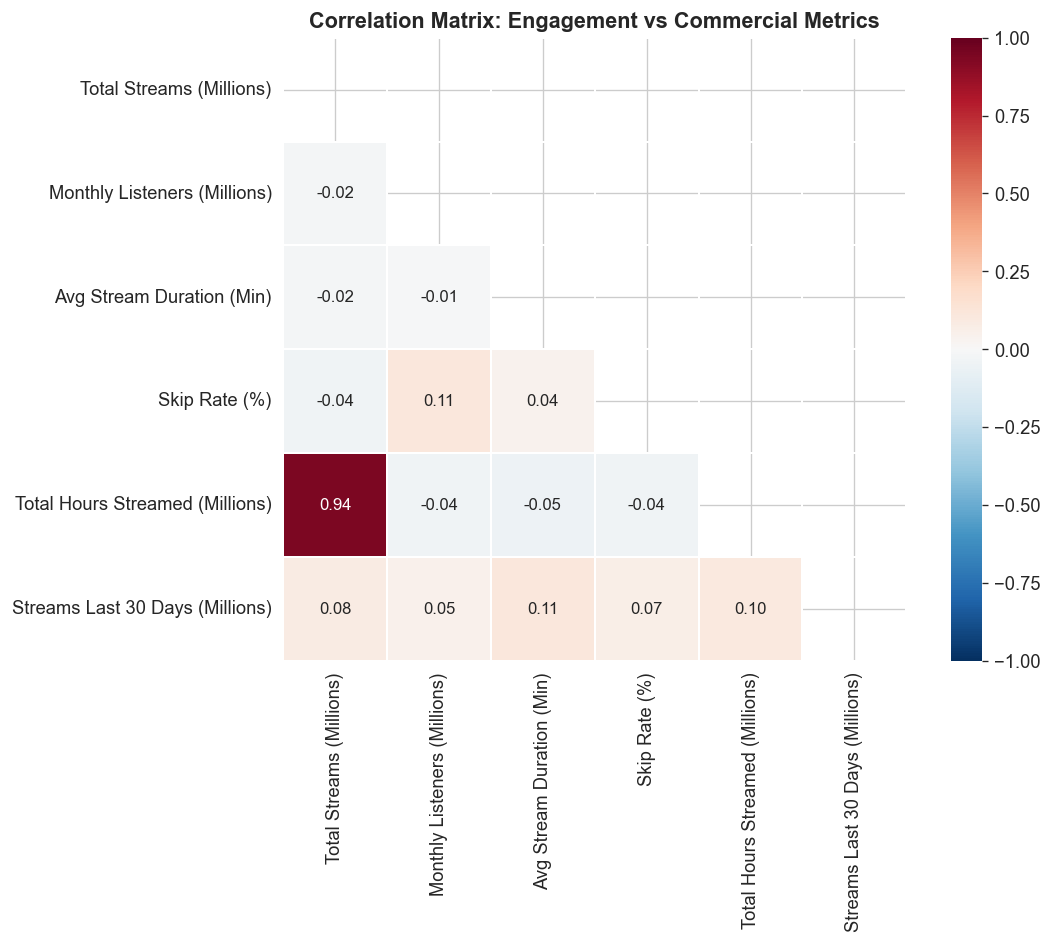

Key correlations:
  Streams ↔ Hours Streamed: 0.94
  Streams ↔ Skip Rate:      -0.04
  Listeners ↔ Duration:     -0.01


In [13]:
# ── Figure 9: Correlation Matrix ──────────────────────────────────────────────
num_cols = [STREAM_COL, LISTENER_COL, DURATION_COL, SKIP_COL, HOURS_COL, RECENT_STREAM_COL]
corr = df_focus[num_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, linewidths=1, fmt='.2f', annot_kws={'fontsize': 10}, ax=ax)
ax.set_title('Correlation Matrix: Engagement vs Commercial Metrics', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('figure_9_correlation.png', bbox_inches='tight')
plt.show()

print("Key correlations:")
print(f"  Streams ↔ Hours Streamed: {corr.loc[STREAM_COL, HOURS_COL]}")
print(f"  Streams ↔ Skip Rate:      {corr.loc[STREAM_COL, SKIP_COL]}")
print(f"  Listeners ↔ Duration:     {corr.loc[LISTENER_COL, DURATION_COL]}")

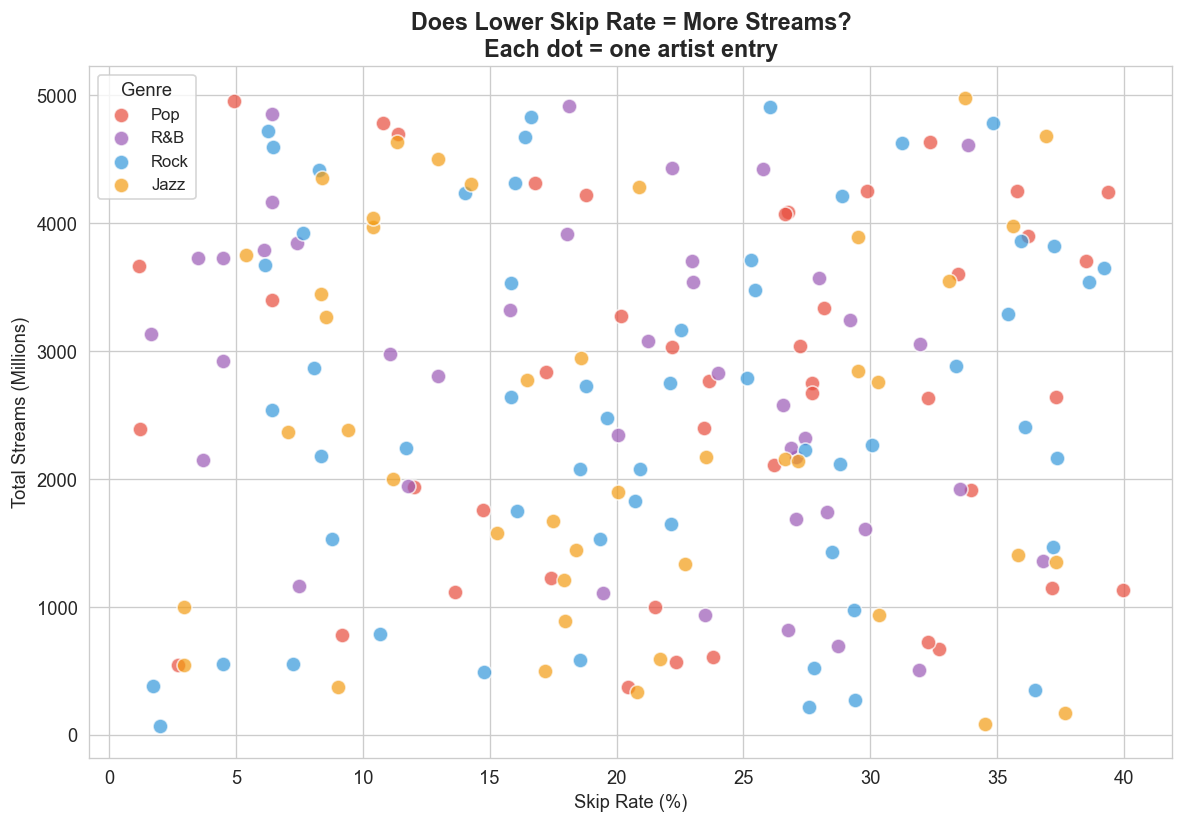

In [14]:
# ── Figure 10: Scatter — Streams vs Skip Rate ────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
for genre in FOCUS_GENRES:
    sub = df_focus[df_focus[GENRE_COL] == genre]
    ax.scatter(sub[SKIP_COL], sub[STREAM_COL], c=GENRE_COLORS[genre],
               label=genre, s=80, alpha=0.7, edgecolors='white')

ax.set_xlabel('Skip Rate (%)'); ax.set_ylabel('Total Streams (Millions)')
ax.set_title('Does Lower Skip Rate = More Streams?\nEach dot = one artist entry',
             fontweight='bold', fontsize=14)
ax.legend(title='Genre', fontsize=10)
plt.tight_layout()
plt.savefig('figure_10_scatter.png', bbox_inches='tight')
plt.show()

Estimated Revenue by Genre:

       Premium Rev ($M)  Ad Rev ($M)  Total Rev ($M)  Rev/Song ($M)
Genre                                                              
Pop              228.43       145.07          373.49           8.49
R&B              228.07       136.67          364.75           8.90
Rock             426.59       126.20          552.79           9.53
Jazz             266.78       100.42          367.20           8.54


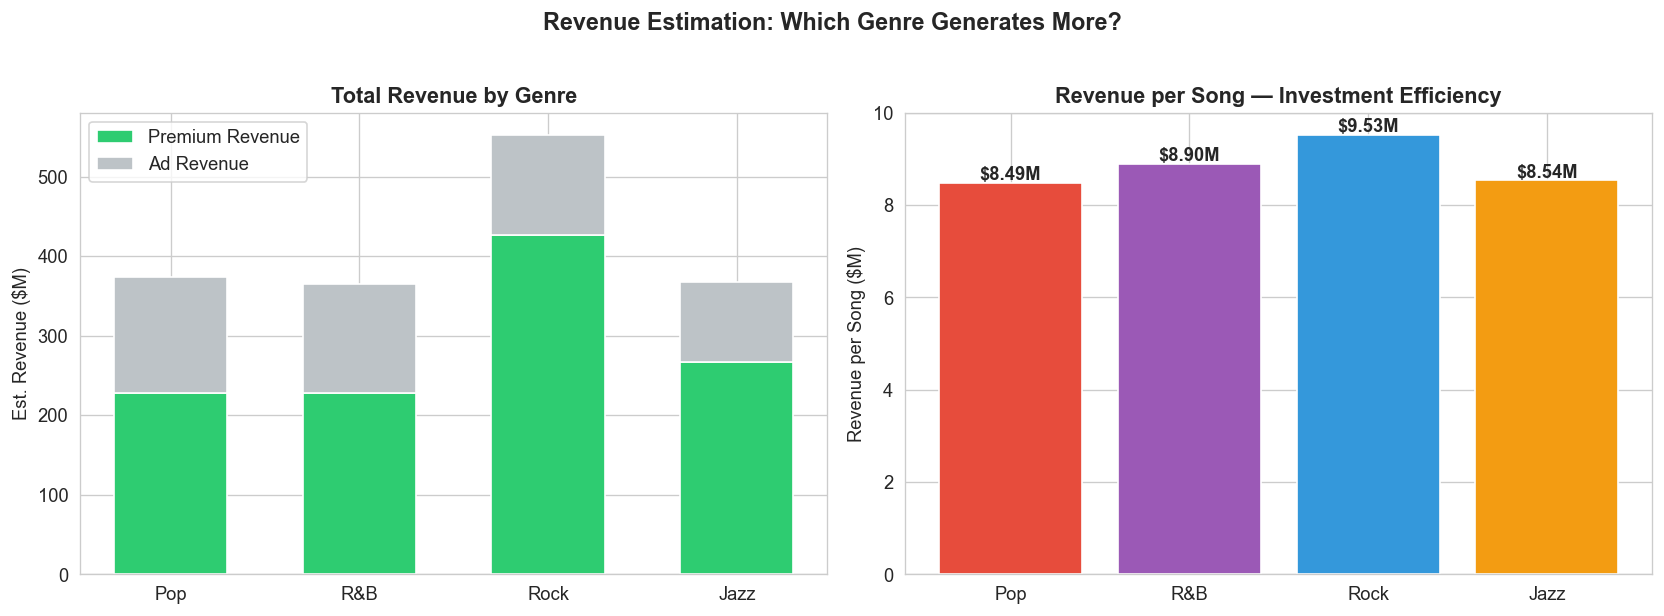

In [15]:
# ── Figure 11: Revenue Estimation ─────────────────────────────────────────────
PREMIUM_RATE = 0.005  # USD per stream (Premium)
FREE_RATE    = 0.002  # USD per stream (Free/Ad-supported)

rev_data = []
for g in FOCUS_GENRES:
    sub = df_focus[df_focus[GENRE_COL] == g]
    prem_rev = sub[sub[PLATFORM_COL]=='Premium'][STREAM_COL].sum() * PREMIUM_RATE
    free_rev = sub[sub[PLATFORM_COL]=='Free'][STREAM_COL].sum() * FREE_RATE
    rev_data.append({'Genre': g, 'Premium Rev ($M)': round(prem_rev,2),
                     'Ad Rev ($M)': round(free_rev,2),
                     'Total Rev ($M)': round(prem_rev+free_rev,2),
                     'Rev/Song ($M)': round((prem_rev+free_rev)/len(sub),2)})

rev_df = pd.DataFrame(rev_data).set_index('Genre')
print("Estimated Revenue by Genre:\n"); print(rev_df)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Revenue Estimation: Which Genre Generates More?', fontsize=14, fontweight='bold', y=1.02)

x = np.arange(len(FOCUS_GENRES))
ax1.bar(x, rev_df['Premium Rev ($M)'], 0.6, label='Premium Revenue', color='#2ECC71')
ax1.bar(x, rev_df['Ad Rev ($M)'], 0.6, bottom=rev_df['Premium Rev ($M)'], label='Ad Revenue', color='#BDC3C7')
ax1.set_xticks(x); ax1.set_xticklabels(FOCUS_GENRES)
ax1.set_ylabel('Est. Revenue ($M)'); ax1.set_title('Total Revenue by Genre', fontweight='bold'); ax1.legend()

bars = ax2.bar(FOCUS_GENRES, rev_df['Rev/Song ($M)'], color=[GENRE_COLORS[g] for g in FOCUS_GENRES], edgecolor='white')
for bar, val in zip(bars, rev_df['Rev/Song ($M)']):
    ax2.text(bar.get_x()+bar.get_width()/2, val+0.05, f'${val:.2f}M', ha='center', fontweight='bold')
ax2.set_title('Revenue per Song — Investment Efficiency', fontweight='bold')
ax2.set_ylabel('Revenue per Song ($M)')
plt.tight_layout()
plt.savefig('figure_11_revenue.png', bbox_inches='tight')
plt.show()

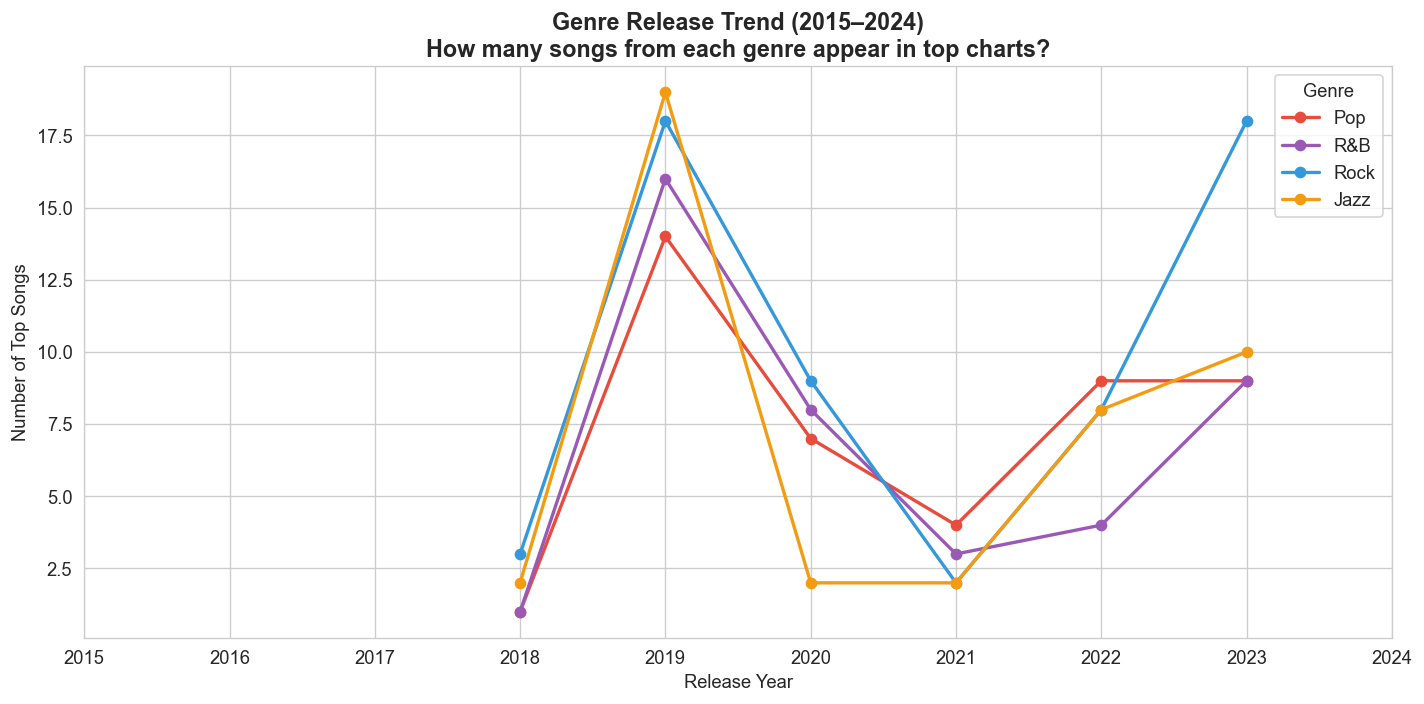

In [16]:
# ── Figure 12: Release Year Trend ─────────────────────────────────────────────
yr = df_focus.groupby([RELEASE_COL, GENRE_COL]).size().unstack(fill_value=0).reindex(columns=FOCUS_GENRES, fill_value=0)
yr = yr[yr.index >= 2015]

fig, ax = plt.subplots(figsize=(12, 6))
for g in FOCUS_GENRES:
    ax.plot(yr.index, yr[g], marker='o', linewidth=2, color=GENRE_COLORS[g], label=g, markersize=6)

ax.set_title('Genre Release Trend (2015–2024)\nHow many songs from each genre appear in top charts?',
             fontweight='bold', fontsize=14)
ax.set_xlabel('Release Year'); ax.set_ylabel('Number of Top Songs')
ax.legend(title='Genre'); ax.set_xticks(range(2015, 2025))
plt.tight_layout()
plt.savefig('figure_12_year_trend.png', bbox_inches='tight')
plt.show()

## 6. Key Findings & Investment Recommendation

### Summary of Findings

| Metric | Winner | Insight |
|--------|--------|---------|
| **Streaming Volume** | R&B | Highest average streams despite smaller audience |
| **Audience Size** | Rock | Largest monthly listener base |
| **Engagement Depth** | R&B | Longest duration + lowest skip rate |
| **Premium Conversion** | Rock | 55% premium — highest willingness to pay |

### Investment Recommendation

**Dual-track strategy recommended:**

1. **Subscription revenue → Invest in Rock** — 55% premium conversion = highest per-user revenue  
2. **Engagement-driven value → Invest in R&B** — Strongest listener loyalty and replay behaviour  
3. **Emerging markets → Watch Jazz** — Surprisingly strong in Turkey, Mexico, South Korea  
4. **Pop = volume play** — High reach but highest skip rate and lowest premium conversion  

### Limitations

- Single-year dataset (2024) — multi-year trends would strengthen the case
- 500 observations across 20 countries is a limited sample
- Spotify not available in China — Asia-Pacific uses proxy markets
- Per-stream rates are industry estimates, not actual Spotify payouts
- Genre classification follows Spotify metadata

In [17]:
# ── Final Summary ─────────────────────────────────────────────────────────────
summary = df_focus.groupby(GENRE_COL).agg(
    Avg_Streams=(STREAM_COL, 'mean'), Avg_Listeners=(LISTENER_COL, 'mean'),
    Avg_Duration=(DURATION_COL, 'mean'), Skip_Rate=(SKIP_COL, 'mean'),
).round(2).reindex(FOCUS_GENRES)

for g in FOCUS_GENRES:
    sub = df_focus[df_focus[GENRE_COL] == g]
    summary.loc[g, 'Premium_Pct'] = round(len(sub[sub[PLATFORM_COL]=='Premium'])/len(sub)*100, 1)

print("═"*60)
print("FINAL SUMMARY TABLE")
print("═"*60)
print(summary)

import os
pngs = sorted([f for f in os.listdir('.') if f.endswith('.png')])
print(f"\n✓ All {len(pngs)} figures saved. Ready for GitHub upload.")
for f in pngs: print(f"  📊 {f}")

════════════════════════════════════════════════════════════
FINAL SUMMARY TABLE
════════════════════════════════════════════════════════════
       Avg_Streams  Avg_Listeners  Avg_Duration  Skip_Rate  Premium_Pct
Genre                                                                  
Pop        2686.80          50.55          3.44      23.13         38.6
R&B        2779.31          50.12          3.62      19.89         36.6
Rock       2558.95          54.65          3.53      21.14         55.2
Jazz       2408.46          52.79          3.43      20.00         46.5

✓ All 15 figures saved. Ready for GitHub upload.
  📊 figure_10_scatter.png
  📊 figure_11_revenue.png
  📊 figure_12_year_trend.png
  📊 figure_1_all_genres_streams.png
  📊 figure_1_genre_metrics.png
  📊 figure_2_all_genres_engagement.png
  📊 figure_2_premium_rate.png
  📊 figure_3_all_genres_premium.png
  📊 figure_3_country_heatmap.png
  📊 figure_4_focus_dashboard.png
  📊 figure_5_premium_analysis.png
  📊 figure_6_country_he

In [1]:
# ── Interactive Tool Link ─────────────────────────────────────────────────────
from IPython.display import display, HTML

STREAMLIT_URL = "https://acc102-minitask-cnz6volhvpvni7uhngvfun.streamlit.app"

display(HTML(f"""
<div style="padding:20px; background:#f0f2f6; border-radius:10px; text-align:center; margin:20px 0;">
    <h2>🎵 Try the Interactive Version</h2>
    <p>Click below to open the Genre Investment Analyser — select your own genres and explore the data interactively.</p>
    <a href="{STREAMLIT_URL}" target="_blank" 
       style="display:inline-block; padding:12px 30px; background:#FF4B4B; color:white; 
              text-decoration:none; border-radius:8px; font-size:16px; font-weight:bold;">
        Open Streamlit App →
    </a>
</div>
"""))